
======================= METRICS DASHBOARD =======================
                            MAE         RMSE     R2
Simple Linear      216,826.3531 272,387.3842 0.3969
Multiple Linear     80,879.0972 100,444.0605 0.9180
Polynomial (Deg 2)  80,886.6720 100,495.1150 0.9179
Lasso Regression    80,879.0968 100,444.0600 0.9180
Decision Tree      162,811.4630 206,184.4271 0.6545



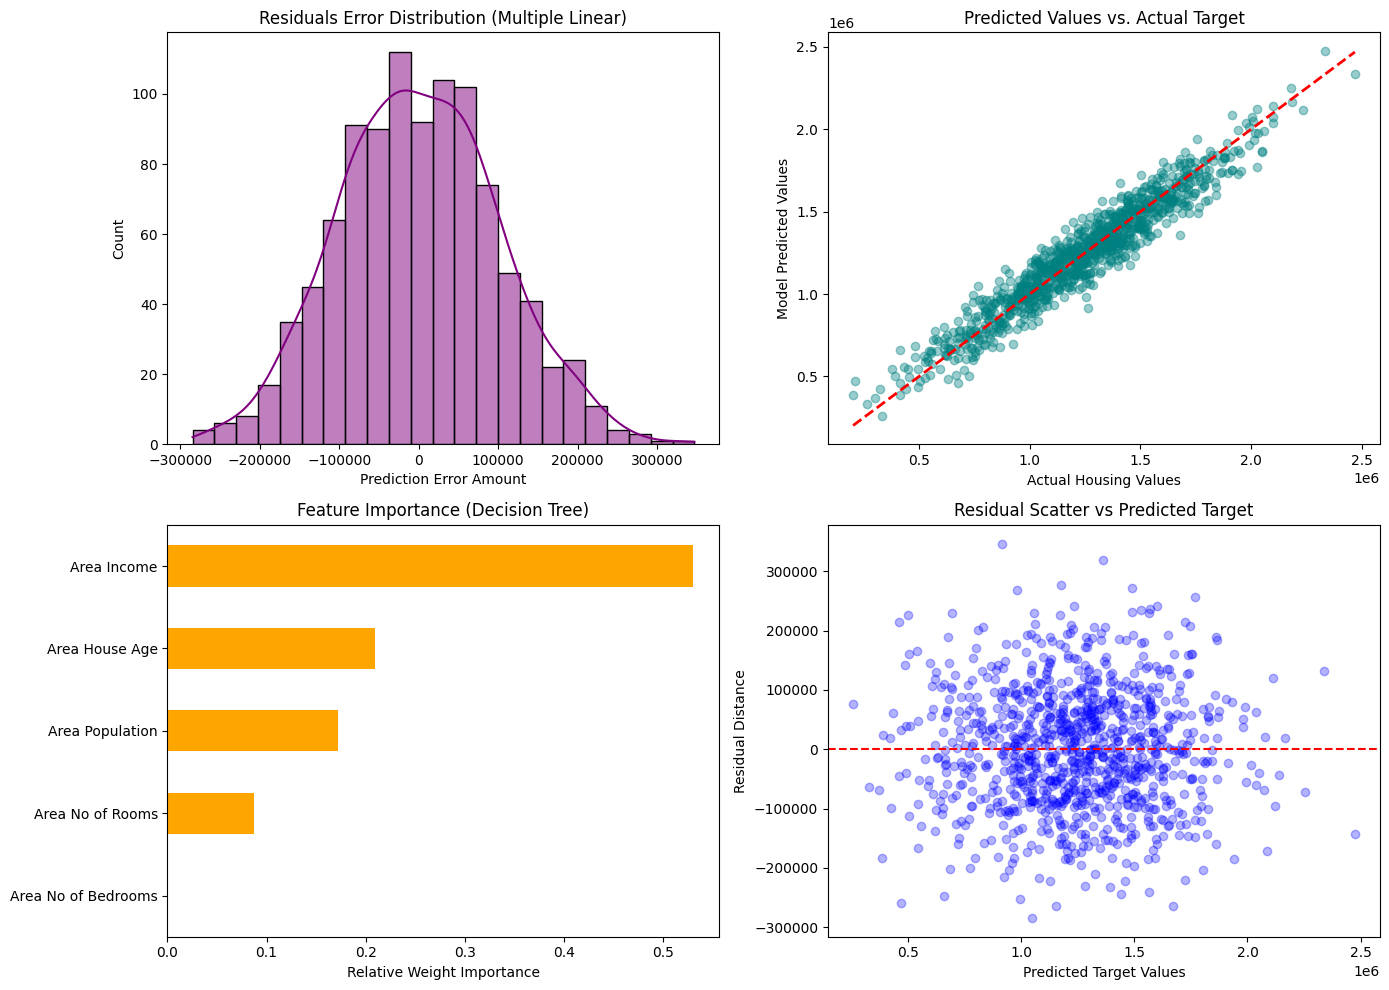

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor

url = "https://raw.githubusercontent.com/mofasa-20/USA-Housing/master/USA_Housing.csv"
df = pd.read_csv(url)
df = df.drop(columns=['Address'], errors='ignore')
df = df.fillna(df.mean(numeric_only=True))

target_col = [col for col in df.columns if 'price' in col.lower()][0]
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

pipelines = {
    'Simple Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Multiple Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Polynomial (Deg 2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', LinearRegression())
    ]),
    'Lasso Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=0.01, max_iter=50000))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', DecisionTreeRegressor(max_depth=5, random_state=42))
    ])
}

results = {}
for name, pipeline in pipelines.items():
    if name == 'Simple Linear':
        pipeline.fit(X_train[[X_train.columns[0]]], y_train)
        preds = pipeline.predict(X_test[[X_train.columns[0]]])
    else:
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)
    results[name] = preds

metrics_df = pd.DataFrame(columns=['MAE', 'RMSE', 'R2'])
for name, preds in results.items():
    metrics_df.loc[name] = [
        mean_absolute_error(y_test, preds),
        np.sqrt(mean_squared_error(y_test, preds)),
        r2_score(y_test, preds)
    ]

print("\n======================= METRICS DASHBOARD =======================")
print(metrics_df.to_string(formatters={c: '{:,.4f}'.format for c in metrics_df.columns}))
print("=================================================================\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

multiple_residuals = y_test - results['Multiple Linear']
sns.histplot(multiple_residuals, kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Residuals Error Distribution (Multiple Linear)')
axes[0, 0].set_xlabel('Prediction Error Amount')

axes[0, 1].scatter(y_test, results['Multiple Linear'], alpha=0.4, color='teal')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('Predicted Values vs. Actual Target')
axes[0, 1].set_xlabel('Actual Housing Values')
axes[0, 1].set_ylabel('Model Predicted Values')

tree_model = pipelines['Decision Tree'].named_steps['regressor']
importances = pd.Series(tree_model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Feature Importance (Decision Tree)')
axes[1, 0].set_xlabel('Relative Weight Importance')

axes[1, 1].scatter(results['Multiple Linear'], multiple_residuals, alpha=0.3, color='blue')
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Residual Scatter vs Predicted Target')
axes[1, 1].set_xlabel('Predicted Target Values')
axes[1, 1].set_ylabel('Residual Distance')

plt.tight_layout()
plt.show()

=== DATASET STRUCTURE ===
Dataset rows and columns: (5000, 6)

Available columns: ['Area Income', 'Area House Age', 'Area No of Rooms', 'Area No of Bedrooms', 'Area Population', 'Price']
   Area Income  Area House Age  Area No of Rooms  Area No of Bedrooms  \
0  79545.45857        5.682861          7.009188                 4.09   
1  79248.64245        6.002900          6.730821                 3.09   
2  61287.06718        5.865890          8.512727                 5.13   
3  63345.24005        7.188236          5.586729                 3.26   
4  59982.19723        5.040555          7.839388                 4.23   

   Area Population         Price  
0      23086.80050  1.059034e+06  
1      40173.07217  1.505891e+06  
2      36882.15940  1.058988e+06  
3      34310.24283  1.260617e+06  
4      26354.10947  6.309435e+05  

=== SPLIT INFO ===
Training rows: 4000, Testing rows: 1000
Using 'Area Income' as the single feature for Simple Regression.

       FINAL TEST EVALUATION RESULTS



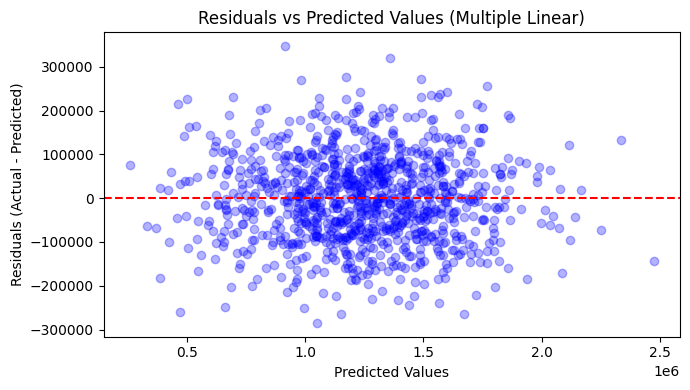

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor

url = "https://raw.githubusercontent.com/mofasa-20/USA-Housing/master/USA_Housing.csv"
df = pd.read_csv(url)

df = df.drop(columns=['Address'], errors='ignore')

print("=== DATASET STRUCTURE ===")
print(f"Dataset rows and columns: {df.shape}\n")
print("Available columns:", list(df.columns))
print(df.head())

df = df.fillna(df.mean(numeric_only=True))


target_col = [col for col in df.columns if 'price' in col.lower()][0]
X = df.drop(columns=[target_col])
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n=== SPLIT INFO ===")
print(f"Training rows: {len(X_train)}, Testing rows: {len(X_test)}")


primary_feature = X_train.columns[0]
print(f"Using '{primary_feature}' as the single feature for Simple Regression.")

X_train_simple = X_train[[primary_feature]]
X_test_simple = X_test[[primary_feature]]

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train)
pred_simple = simple_lr.predict(X_test_simple)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

multiple_lr = LinearRegression()
multiple_lr.fit(X_train_scaled, y_train)
pred_multiple = multiple_lr.predict(X_test_scaled)

poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_transformer.fit_transform(X_train_scaled)
X_test_poly = poly_transformer.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
pred_poly = poly_model.predict(X_test_poly)

lasso_model = Lasso(alpha=0.01, max_iter=50000)
lasso_model.fit(X_train_scaled, y_train)
pred_lasso = lasso_model.predict(X_test_scaled)

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train_scaled, y_train)
pred_tree = tree_model.predict(X_test_scaled)


all_predictions = {
    'Simple Linear': pred_simple,
    'Multiple Linear': pred_multiple,
    'Polynomial (Deg 2)': pred_poly,
    'Lasso Regression': pred_lasso,
    'Decision Tree': pred_tree
}

print("\n" + "="*40)
print("       FINAL TEST EVALUATION RESULTS")
print("="*40)

for model_name, preds in all_predictions.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"\n>>> {model_name} Results:")
    print(f"    Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"    Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"    R-squared Score (R2):          {r2:.4f}")


residuals = y_test - pred_multiple

plt.figure(figsize=(7, 4))
plt.scatter(pred_multiple, residuals, alpha=0.3, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values (Multiple Linear)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.show()